In [1]:
import utils as ut
import pandas as pd

# Validation

#### W tuning results and performance relative to benchmarks

In [6]:
static_benchmarks = pd.read_parquet(f'{ut.results_dir}/benchmarks/nll_only/')
ll_tuning_run = pd.read_parquet(f'{ut.results_dir}/LL_runner/nll_only/')

# Selecting relevant columns
ll_tuning_run['model_name'] = ll_tuning_run['hurdle_model'].map({True: 'LL_hurdle', False: 'LL_NB'})
ll_tuning_run = ll_tuning_run[['w_inf', 'model_name', 'test_valid', 'non_degen_ll', 'run_timestamp']]
static_benchmarks['w_inf'] = 0

results = pd.concat([ll_tuning_run, static_benchmarks])
results.sort_values(by='non_degen_ll', ascending=False).head()

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp,experiment_name,seed,hurdle_model
4,0.25,LL_hurdle,valid,-1.406662,20260810_155952_798324,NaN,NaN,NaN
14,0.26,LL_hurdle,valid,-1.406713,20260810_170528_560531,NaN,NaN,NaN
13,0.24,LL_hurdle,valid,-1.406725,20260810_170420_378925,NaN,NaN,NaN
15,0.27,LL_hurdle,valid,-1.406875,20260810_170636_462556,NaN,NaN,NaN
12,0.23,LL_hurdle,valid,-1.406901,20260810_170310_618712,NaN,NaN,NaN


In [7]:
results = results.reset_index(drop=True)
results.loc[results.groupby('model_name')['non_degen_ll'].idxmax()].sort_values(by='non_degen_ll', ascending=False)

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp,experiment_name,seed,hurdle_model
4,0.25,LL_hurdle,valid,-1.406662,20260810_155952_798324,NaN,NaN,NaN
19,0.00,static_user_hour_hurdle,valid,-1.491693,20260810_165734_822592,benchmark,6654.0,True
18,0.00,static_user_hurdle,valid,-1.491866,20260810_165734_822592,benchmark,6654.0,True


#### Cluster Smoothing validaiton performance

In [2]:
cluster_smoothing = pd.read_parquet(f'{ut.results_dir}/cluster_smoothing/nll_only/')

In [3]:
cluster_smoothing.sort_values(by='non_degen_ll', ascending=False).head(10)

,smoothed_model_name,experiment_name,seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,constant_alpha,smoothing_target,hurdle_model,test_valid,non_degen_ll,clustering_matrix_name,clustering_transformation,distance_metric,cluster_inertia,run_timestamp
328,k_clusters,cluster_smoothing,6654,0.31,16,0.65,0.60,0.35,0.0,0.0,...,True,1,True,valid,-1.398561,all,none,standardised_l2,155291.875000,20260811_034150_848030
321,k_clusters,cluster_smoothing,6654,0.33,16,0.50,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.398697,all,none,standardised_l2,155291.875000,20260811_033212_240184
373,k_clusters,cluster_smoothing,6654,0.31,28,0.50,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.398750,all,none,standardised_l2,107447.562500,20260811_044353_006559
291,k_clusters,cluster_smoothing,6654,0.31,20,0.55,0.55,0.20,0.0,0.0,...,True,1,True,valid,-1.398808,u_p,none,standardised_l2,106852.945312,20260811_025048_550944
333,k_clusters,cluster_smoothing,6654,0.32,22,0.40,0.50,0.20,0.0,0.0,...,True,1,True,valid,-1.398858,all,none,standardised_l2,121895.039062,20260811_034844_211758
344,k_clusters,cluster_smoothing,6654,0.33,26,0.55,0.60,0.20,0.0,0.0,...,True,1,True,valid,-1.398929,all,none,standardised_l2,112232.984375,20260811_040353_923753
336,k_clusters,cluster_smoothing,6654,0.31,32,0.60,0.55,0.30,0.0,0.0,...,True,1,True,valid,-1.398990,u_p,none,standardised_l2,79655.664062,20260811_035253_049372
271,k_clusters,cluster_smoothing,6654,0.32,18,0.40,0.45,0.25,0.0,0.0,...,True,1,True,valid,-1.398997,all,none,standardised_l2,138624.796875,20260811_022313_145784
383,k_clusters,cluster_smoothing,6654,0.31,32,0.45,0.45,0.25,0.0,0.0,...,True,1,True,valid,-1.399133,u_p,none,standardised_l2,79655.664062,20260811_045739_261145
10,k_clusters,cluster_smoothing,6654,0.34,24,0.60,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.399162,all,none,standardised_l2,118243.179688,20260810_172808_880450


In [3]:
cluster_smoothing.sort_values(by='non_degen_ll', ascending=False).iloc[0]

smoothed_model_name                      k_clusters
experiment_name                   cluster_smoothing
seed                                           6654
w_inf                                          0.31
cluster_param                                    16
smooth_a_mu                                    0.65
smooth_a_sigma2                                 0.6
smooth_a_p                                     0.35
smooth_t_mu                                     0.0
smooth_t_sigma2                                 0.0
smooth_t_p                                      0.0
constant_alpha                                 True
smoothing_target                                  1
hurdle_model                                   True
test_valid                                    valid
non_degen_ll                              -1.398561
clustering_matrix_name                          all
clustering_transformation                      none
distance_metric                     standardised_l2
cluster_iner

#### Global Smoothing Validation performance

In [ ]:
global_smoothing = pd.read_parquet(f'{ut.results_dir}/global_smoothing/nll_only/')

In [12]:
global_smoothing.sort_values(by='non_degen_ll', ascending=False).head()

,smoothed_model_name,experiment_name,seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,constant_alpha,smoothing_target,hurdle_model,test_valid,non_degen_ll,clustering_matrix_name,clustering_transformation,distance_metric,cluster_inertia,run_timestamp
297,k_clusters,global_smoothing,6654,0.28,1,0.45,0.45,0.1,0.0,0.0,...,True,1,True,valid,-1.404316,u,none,l2,0.0,20260811_085154_514265
363,k_clusters,global_smoothing,6654,0.28,1,0.50,0.45,0.1,0.0,0.0,...,True,1,True,valid,-1.404364,u,none,l2,0.0,20260811_100554_975036
229,k_clusters,global_smoothing,6654,0.30,1,0.50,0.50,0.1,0.0,0.0,...,True,1,True,valid,-1.404461,u,none,l2,0.0,20260811_073523_810971
334,k_clusters,global_smoothing,6654,0.28,1,0.50,0.60,0.1,0.0,0.0,...,True,1,True,valid,-1.404567,u,none,l2,0.0,20260811_093456_073988
352,k_clusters,global_smoothing,6654,0.28,1,0.60,0.65,0.1,0.0,0.0,...,True,1,True,valid,-1.404767,u,none,l2,0.0,20260811_095546_369211


In [13]:
global_smoothing.sort_values(by='non_degen_ll', ascending=False).iloc[0]

smoothed_model_name                      k_clusters
experiment_name                    global_smoothing
seed                                           6654
w_inf                                          0.28
cluster_param                                     1
smooth_a_mu                                    0.45
smooth_a_sigma2                                0.45
smooth_a_p                                      0.1
smooth_t_mu                                     0.0
smooth_t_sigma2                                 0.0
smooth_t_p                                      0.0
constant_alpha                                 True
smoothing_target                                  1
hurdle_model                                   True
test_valid                                    valid
non_degen_ll                              -1.404316
clustering_matrix_name                            u
clustering_transformation                      none
distance_metric                                  l2
cluster_iner

# Test

In [1]:
import l_result_preperation as l
import matplotlib.pyplot as plt
import numpy as np 
import utils as ut
import os 
import m_plots as m

outputs_dir = f'{ut.project_root}/outputs'
os.makedirs(outputs_dir, exist_ok=True)

In [2]:
# Loading in test results and concat together
runtime_configs = ut.load_json5('runtime_configs')
ll_full_results, ll_user_results, benchmark_results = l.load_test_results(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])

##### Processing Data

In [3]:
overall_performance = l.get_all_model_performance_table(ll_full_results=ll_full_results, benchmark_results=benchmark_results)
l.store_results(overall_performance, ut.results_dir, 'overall_performance')

In [4]:
model_comparisons = l.prepare_model_comparisons(ll_user_results=ll_user_results, overall_performance=overall_performance)
l.store_results(model_comparisons, ut.results_dir, 'model_comparisons')

In [5]:
activity_decile = l.get_activity_decile_improvement(ll_full_results=ll_full_results)
l.store_results(activity_decile, ut.results_dir, 'activity_decile')

In [6]:
distance_decile = l.get_distance_decile_improvement(ll_user_results=ll_user_results)
l.store_results(distance_decile, ut.results_dir, 'distance_decile')

In [7]:
calibration = l.get_calibration_summary(ll_full_results=ll_full_results)
l.store_results(calibration, ut.results_dir, 'calibration')

In [8]:
user_type_summary = l.get_user_type_summary(ll_full_results=ll_full_results, benchmark_results=benchmark_results)
l.store_results(user_type_summary, ut.results_dir, 'user_type_summary')

In [9]:
detection = l.get_attack_detection_summary(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])
l.store_results(detection, ut.results_dir, 'attack_detection')

##### Activity decile plot

In [9]:
# activity_decile = l.load_results( ut.results_dir, 'activity_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=False)
# # fig.savefig(f'{outputs_dir}/activity_decile.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

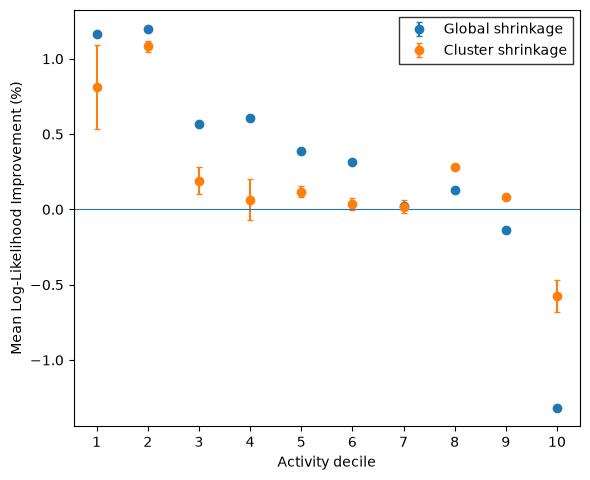

In [10]:
activity_decile = l.load_results(ut.results_dir, 'activity_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=True)
fig.savefig(f'{outputs_dir}/activity_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Distance decile plot

In [11]:
# distance_decile = l.load_results( ut.results_dir, 'distance_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=False)
# # fig.savefig(f'{outputs_dir}/distance_decile.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

In [12]:
# distance_decile = l.load_results(ut.results_dir, 'distance_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=True)
# fig.savefig(f'{outputs_dir}/distance_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

##### Calibration plot

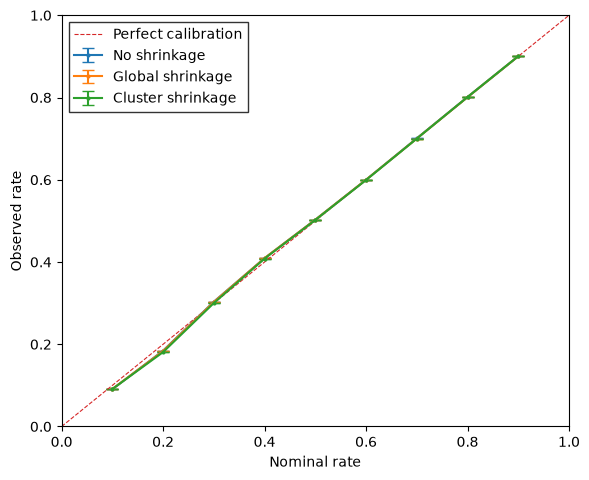

In [22]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=False)
# fig.savefig(f'{outputs_dir}/decile_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Extreme Calibration Table + plot

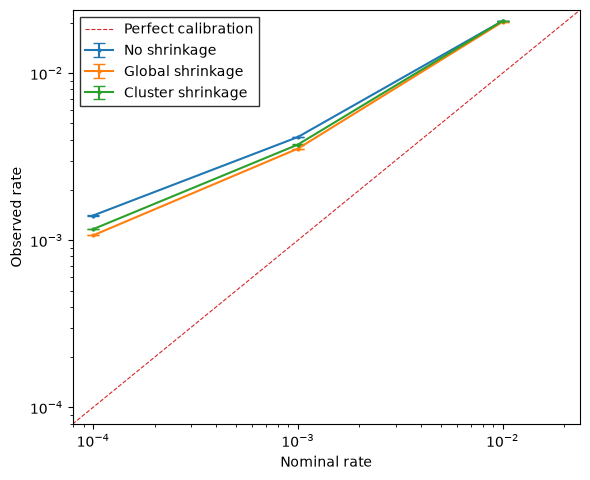

In [ ]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=True)
# fig.savefig(f'{outputs_dir}/extreme_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [6]:
# calibration = l.load_results(ut.results_dir, 'calibration',)
# extreme_calibration_output = l.get_extreme_calibration_output(calibration)
# extreme_calibration_output

# extreme_calibration_output.to_csv(f'{outputs_dir}/extreme_calibration.csv', index=False)

##### User Type Breakdown Table

In [15]:
user_type_summary = l.load_results(ut.results_dir, 'user_type_summary')
user_type_output = l.get_user_type_output(user_type_summary)


user_type_output['No shrinkage'] = user_type_output['no_smoothing'].apply(lambda x: f'{x:.5f}')
user_type_output['Global shrinkage'] = user_type_output['global_smoothing'].apply(lambda x: f'{x:.5f}')
user_type_output['Cluster shrinkage'] = np.where(
    user_type_output['cluster_smoothing_seed_sd'].notna(),
    user_type_output['cluster_smoothing'].apply(lambda x: f'{x:.5f}') + ' $\pm$ ' + user_type_output['cluster_smoothing_seed_sd'].apply(lambda x: f'{x:.5f}'),
    user_type_output['cluster_smoothing'].apply(lambda x: f'{x:.5f}'))

user_type_output = user_type_output[['user_type', 'No shrinkage', 'Global shrinkage', 'Cluster shrinkage']].rename(columns={'user_type': 'User type'})
# user_type_output.to_csv(f'{outputs_dir}/user_type_performance.csv', index=False)

##### Overall Comparison Table

In [11]:
overall_performance = l.load_results(ut.results_dir, 'overall_performance')
user_type_summary = l.load_results(ut.results_dir, 'user_type_summary')
overall_performance_output = l.get_overall_performance_output(overall_performance, user_type_summary)
overall_performance_output
#overall_performance_output.to_csv(f'{outputs_dir}/overall_performance.csv', index=False)

,Model,Overall,$\Delta$ LL,Human,Machine
0,Cluster shrinkage,-1.37401 $\pm$ 0.00027,+0.00042,-1.01573 $\pm$ 0.00071,-1.61426 $\pm$ 0.00029
1,No shrinkage,-1.37442,-,-1.00846,-1.61983
2,Global shrinkage,-1.37502,-0.00060,-1.01257,-1.61807
3,Hourly user benchmark,-1.45200,-0.07758,-1.05447,-1.71857
4,User level benchmark,-1.45571,-0.08129,-1.04767,-1.72933


##### 3 Way comparison table

In [17]:
model_comparisons = l.load_results( ut.results_dir, 'model_comparisons')
model_comparison_output = l.get_model_comparison_output(model_comparisons)
model_comparison_output = model_comparison_output

model_comparison_output['mean_log_likelihood_difference']  = model_comparison_output['mean_log_likelihood_difference'].apply(lambda x: f'{x:.5f}')
model_comparison_output['users_improved_pct']  = model_comparison_output['users_improved_pct'].apply(lambda x: f'{x:.5f}')
model_comparison_output['median_user_ll_difference']  = model_comparison_output['median_user_ll_difference'].apply(lambda x: f'{x:.5f}')

model_comparison_output = model_comparison_output[['model_comparison', 'mean_log_likelihood_difference', 'users_improved_pct', 'median_user_ll_difference']]
model_comparison_output = model_comparison_output.rename(columns={
    'mean_log_likelihood_difference' : 'Mean Log-Likelihood $\Delta$',
    'users_improved_pct' : 'Users Improved (\%)',
    'median_user_ll_difference' : 'Median Improvement',
    'model_comparison' : 'Model Comparison'})

model_comparison_output
#model_comparison_output.to_csv(f'{outputs_dir}/model_comparisons.csv', index=False)

,Model Comparison,Mean Log-Likelihood $\Delta$,Users Improved (\%),Median Improvement
0,Global shrinkage vs No shrinkage,-0.00060,78.37228,0.00318
1,Cluster shrinkage vs No shrinkage,0.00042,72.90896,0.00393
2,Cluster shrinkage vs Global shrinkage,0.00101,62.55526,0.00093


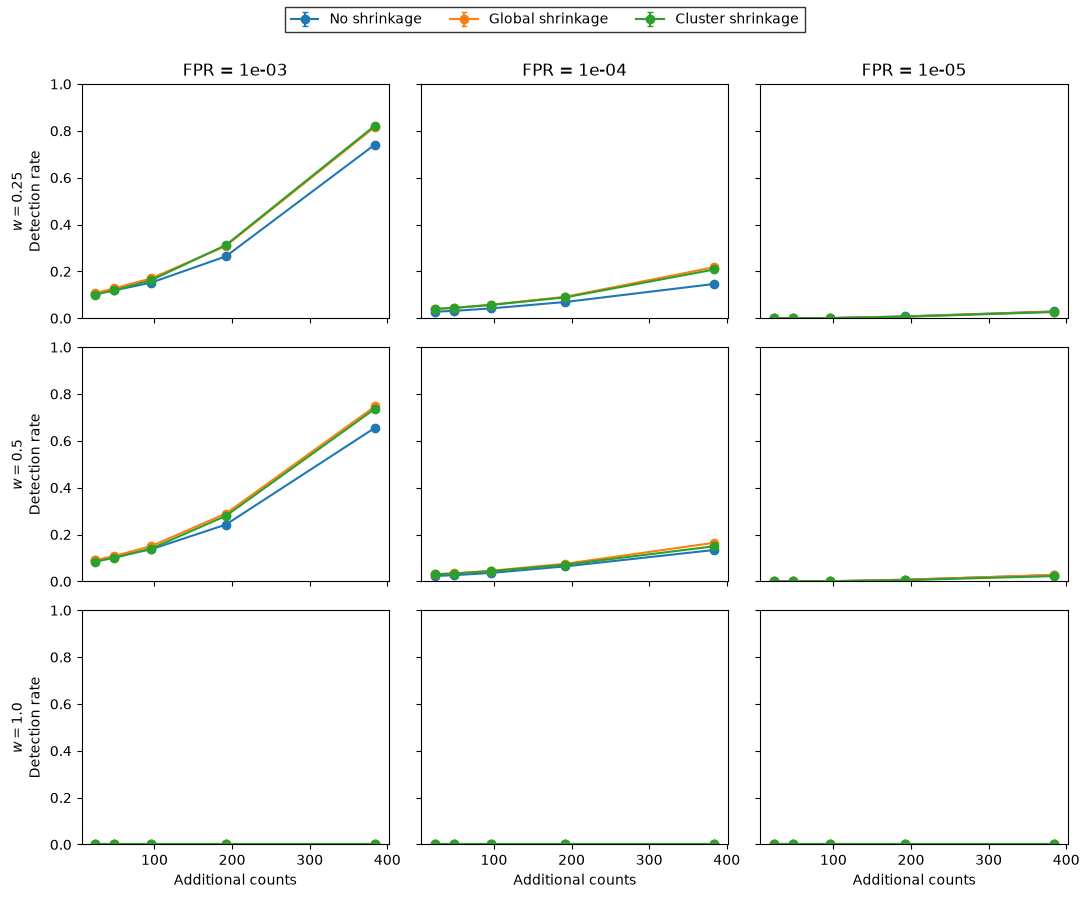

In [16]:
import matplotlib.pyplot as plt
import l_result_preperation as l
import utils as ut

runtime_configs = ut.load_json5('runtime_configs')

detection = l.get_attack_detection_summary(
    results_dir=ut.results_dir,
    n_test_seeds=runtime_configs['n_test_seeds'])

alert_ws = [0.25, 0.5, 1.0]
fpr_rates = [1e-3, 1e-4, 1e-5]

fig, axes = plt.subplots(3, 3, figsize=(11, 9), sharex=True, sharey=True)

for row, alert_w in enumerate(alert_ws):
    for col, fpr_rate in enumerate(fpr_rates):
        ax = axes[row, col]

        for model in ('no_smoothing', 'global_smoothing', 'cluster_smoothing'):
            model_results = detection.loc[
                (detection['experiment_name'] == model) &
                (detection['alert_w'] == alert_w) &
                (detection['fpr_rate'] == fpr_rate)
            ].sort_values('attack_size')

            ax.errorbar(
                model_results['attack_size'],
                model_results['detection_mean'],
                yerr=model_results['detection_sd'],
                marker='o',
                capsize=2,
                label=l.model_labels[model])

        if row == 0:
            ax.set_title(f'FPR = {fpr_rate:.0e}')

        if col == 0:
            ax.set_ylabel(f'$w={alert_w}$\nDetection rate')

        if row == 2:
            ax.set_xlabel('Additional counts')

        ax.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fancybox=False, edgecolor='black')

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [22]:
import numpy as np
import pandas as pd
from scipy.special import ndtri

import l_result_preperation as l
import utils as ut

runtime_configs = ut.load_json5('runtime_configs')

detection = l.get_attack_detection_summary(
    results_dir=ut.results_dir,
    n_test_seeds=runtime_configs['n_test_seeds'])

# Threshold is identical across attack sizes, so remove the repeated rows
threshold_check = (
    detection[
        ['experiment_name', 'alert_w', 'fpr_rate',
         'threshold_mean', 'threshold_sd']
    ]
    .drop_duplicates()
    .assign(
        threshold_sd_pct=lambda d:
            100 * d['threshold_sd'] / d['threshold_mean'],

        theoretical_ewma_sd=lambda d:
            np.sqrt(d['alert_w'] / (2 - d['alert_w'])),

        theoretical_threshold=lambda d:
            -ndtri(d['fpr_rate']) * d['theoretical_ewma_sd'],

        threshold_vs_theory=lambda d:
            d['threshold_mean'] / d['theoretical_threshold'],

        distance_from_z_cap=lambda d:
            -ndtri(1e-30) - d['threshold_mean']
    )
    .sort_values(
        ['alert_w', 'fpr_rate', 'experiment_name'],
        ascending=[True, False, True])
    .reset_index(drop=True)
)

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.float_format', '{:.4f}'.format):

    display(threshold_check)

,experiment_name,alert_w,fpr_rate,threshold_mean,threshold_sd,threshold_sd_pct,theoretical_ewma_sd,theoretical_threshold,threshold_vs_theory,distance_from_z_cap
0,cluster_smoothing,0.2500,0.0010,2.5052,0.0023,0.0912,0.3780,1.1680,2.1448,8.9589
1,global_smoothing,0.2500,0.0010,2.4978,0.0005,0.0201,0.3780,1.1680,2.1385,8.9662
2,no_smoothing,0.2500,0.0010,2.6419,0.0010,0.0380,0.3780,1.1680,2.2619,8.8221
3,cluster_smoothing,0.2500,0.0001,3.7051,0.0067,0.1808,0.3780,1.4057,2.6359,7.7589
4,global_smoothing,0.2500,0.0001,3.6352,0.0017,0.0470,0.3780,1.4057,2.5861,7.8288
5,no_smoothing,0.2500,0.0001,4.1603,0.0027,0.0648,0.3780,1.4057,2.9597,7.3037
6,cluster_smoothing,0.2500,0.0000,6.8316,0.0406,0.5950,0.3780,1.6120,4.2381,4.6324
7,global_smoothing,0.2500,0.0000,6.4875,0.0070,0.1080,0.3780,1.6120,4.0245,4.9766
8,no_smoothing,0.2500,0.0000,6.6546,0.0076,0.1140,0.3780,1.6120,4.1282,4.8094
9,cluster_smoothing,0.5000,0.0010,2.8525,0.0024,0.0842,0.5774,1.7841,1.5988,8.6115


In [23]:
import os
import numpy as np
import pandas as pd

import l_result_preperation as l
import utils as ut

models = (
    'no_smoothing',
    'global_smoothing',
    'cluster_smoothing')

raw_results = []

for model in models:
    directory = f'{ut.results_dir}/test/{model}/detection'

    # Read however many seed files currently exist
    model_results = l.safe_read(directory=directory).assign(
        model=model)

    raw_results.append(model_results)

    print(
        model,
        '| files:', len(os.listdir(directory)),
        '| seeds:', model_results['seed'].nunique(),
        '| rows:', len(model_results))

detection_raw = pd.concat(raw_results, ignore_index=True)

# Check the raw thresholds for NaN / inf
raw_check = (
    detection_raw
    .groupby(
        ['model', 'alert_w', 'fpr_rate'],
        as_index=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        n_rows=('threshold', 'size'),
        n_threshold_nan=('threshold', lambda x: x.isna().sum()),
        n_threshold_inf=('threshold', lambda x: np.isinf(x).sum()),
        threshold_min=('threshold', 'min'),
        threshold_max=('threshold', 'max'))
)

display(raw_check)

# Show the actual offending raw rows, if there are any
bad_rows = detection_raw.loc[
    detection_raw['threshold'].isna() |
    np.isinf(detection_raw['threshold'])
].sort_values(
    ['model', 'alert_w', 'fpr_rate', 'seed', 'attack_size'])

display(bad_rows)

no_smoothing | files: 100 | seeds: 100 | rows: 4500
global_smoothing | files: 15 | seeds: 15 | rows: 675
cluster_smoothing | files: 100 | seeds: 100 | rows: 4500


,model,alert_w,fpr_rate,n_seeds,n_rows,n_threshold_nan,n_threshold_inf,threshold_min,threshold_max
0,cluster_smoothing,0.25,0.00001,100,500,0,0,6.747002,6.950096
1,cluster_smoothing,0.25,0.00010,100,500,0,0,3.691164,3.727363
2,cluster_smoothing,0.25,0.00100,100,500,0,0,2.501236,2.513085
3,cluster_smoothing,0.50,0.00001,100,500,0,0,7.374822,7.690690
4,cluster_smoothing,0.50,0.00010,100,500,0,0,4.240527,4.281222
5,cluster_smoothing,0.50,0.00100,100,500,0,0,2.848065,2.860548
6,cluster_smoothing,1.00,0.00001,100,500,500,0,NaN,NaN
7,cluster_smoothing,1.00,0.00010,100,500,500,0,NaN,NaN
8,cluster_smoothing,1.00,0.00100,100,500,500,0,NaN,NaN
9,global_smoothing,0.25,0.00001,15,75,0,0,6.473457,6.498235


,experiment_name,seed,alert_w,fpr_rate,attack_size,threshold,n_attacks,n_detected,run_timestamp,model
6880,cluster_smoothing,10,1.0,0.00001,24,NaN,22161,0,20260813_052420_484557,cluster_smoothing
6881,cluster_smoothing,10,1.0,0.00001,48,NaN,22161,0,20260813_052420_484557,cluster_smoothing
6882,cluster_smoothing,10,1.0,0.00001,96,NaN,22161,0,20260813_052420_484557,cluster_smoothing
6883,cluster_smoothing,10,1.0,0.00001,192,NaN,22161,0,20260813_052420_484557,cluster_smoothing
6884,cluster_smoothing,10,1.0,0.00001,384,NaN,22161,0,20260813_052420_484557,cluster_smoothing
...,...,...,...,...,...,...,...,...,...,...
3135,no_smoothing,9875,1.0,0.00100,24,NaN,22161,0,20260813_031954_735780,no_smoothing
3136,no_smoothing,9875,1.0,0.00100,48,NaN,22161,0,20260813_031954_735780,no_smoothing
3137,no_smoothing,9875,1.0,0.00100,96,NaN,22161,0,20260813_031954_735780,no_smoothing
3138,no_smoothing,9875,1.0,0.00100,192,NaN,22161,0,20260813_031954_735780,no_smoothing


In [24]:
float(np.nextafter(np.float32(1.0), np.float32(0.0)))

0.9999999403953552

In [25]:
float(np.finfo(np.float32).tiny)

1.1754943508222875e-38